In [ ]:
!pip install tensorflow matplotlib numpy


#Basic Level – Fashion-MNIST

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# Cargar el dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Preprocesar los datos (escalado de 0 a 1)
x_train, x_test = x_train / 255.0, x_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Crear un modelo secuencial
model = Sequential([
    Flatten(input_shape=(28, 28)),  # Aplana la imagen 28x28 a un vector de 784 elementos
    Dense(128, activation='relu'),  # Capa densa con 128 neuronas y función de activación ReLU
    Dense(10, activation='softmax')  # Capa de salida con 10 clases (una para cada categoría de ropa)
])

# Compilar el modelo
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Entrenar el modelo utilizando CPU
import time

# Iniciar temporizador
start_time = time.time()

# Entrenamiento en CPU
with tf.device('/CPU:0'):
    history_cpu = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Medir el tiempo de entrenamiento en CPU
end_time = time.time()
cpu_time = end_time - start_time
print(f"Tiempo de entrenamiento en CPU: {cpu_time} segundos")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7789 - loss: 0.6290 - val_accuracy: 0.8485 - val_loss: 0.4217
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8610 - loss: 0.3836 - val_accuracy: 0.8536 - val_loss: 0.3958
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8746 - loss: 0.3436 - val_accuracy: 0.8697 - val_loss: 0.3595
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8833 - loss: 0.3159 - val_accuracy: 0.8775 - val_loss: 0.3451
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8941 - loss: 0.2870 - val_accuracy: 0.8729 - val_loss: 0.3629
Tiempo de entrenamiento en CPU: 39.69809818267822 segundos


In [ ]:
# Entrenar el modelo utilizando GPU
start_time = time.time()

# Entrenamiento en GPU
with tf.device('/GPU:0'):
    history_gpu = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Medir el tiempo de entrenamiento en GPU
end_time = time.time()
gpu_time = end_time - start_time
print(f"Tiempo de entrenamiento en GPU: {gpu_time} segundos")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8963 - loss: 0.2795 - val_accuracy: 0.8732 - val_loss: 0.3567
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9004 - loss: 0.2675 - val_accuracy: 0.8773 - val_loss: 0.3427
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9040 - loss: 0.2533 - val_accuracy: 0.8798 - val_loss: 0.3451
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9101 - loss: 0.2432 - val_accuracy: 0.8810 - val_loss: 0.3376
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9116 - loss: 0.2412 - val_accuracy: 0.8829 - val_loss: 0.3461
Tiempo de entrenamiento en GPU: 38.655741691589355 segundos


In [ ]:
print(f"Tiempo total de entrenamiento en CPU: {cpu_time:.2f} segundos")
print(f"Tiempo total de entrenamiento en GPU: {gpu_time:.2f} segundos")


Tiempo total de entrenamiento en CPU: 39.70 segundos
Tiempo total de entrenamiento en GPU: 38.66 segundos


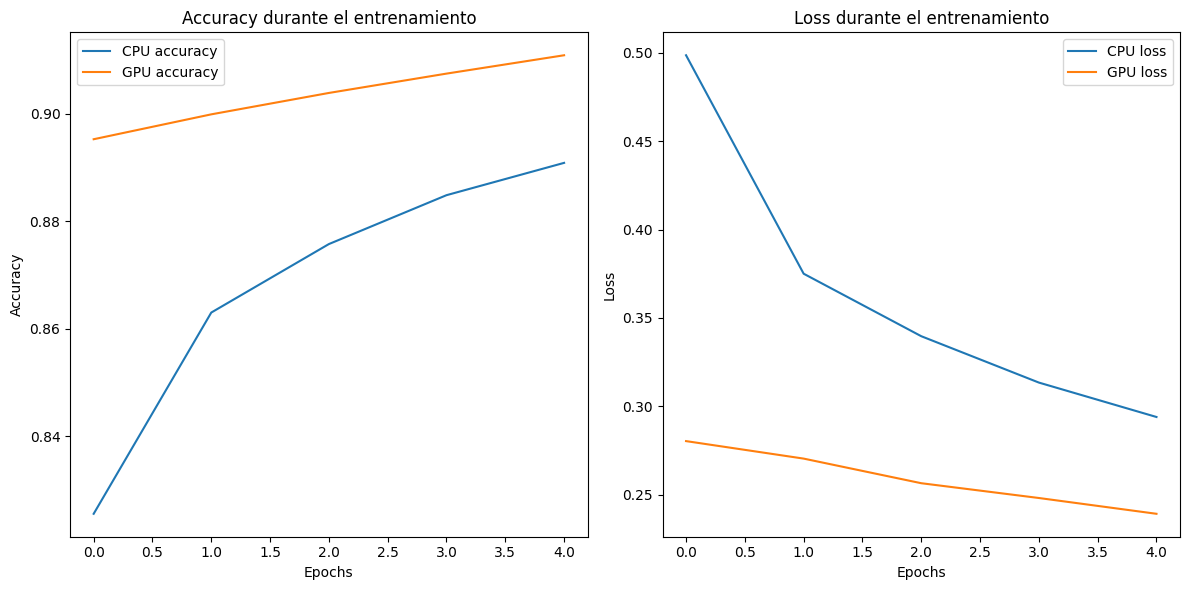

In [ ]:
import matplotlib.pyplot as plt

# Graficar la precisión y la pérdida
plt.figure(figsize=(12, 6))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history_cpu.history['accuracy'], label='CPU accuracy')
plt.plot(history_gpu.history['accuracy'], label='GPU accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_cpu.history['loss'], label='CPU loss')
plt.plot(history_gpu.history['loss'], label='GPU loss')
plt.title('Loss durante el entrenamiento')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

####Interpretación

#####El entrenamiento en la GPU tiene una convergencia más rápida, es decir, el modelo alcanza una mayor precisión en menos épocas. Esto es típico cuando se usa una GPU para entrenamiento de redes neuronales, ya que las GPUs son mucho más eficientes en operaciones paralelizadas y pueden manejar más cálculos simultáneamente.



#####El entrenamiento en la GPU también presenta una disminución más rápida de la pérdida. Esto se debe a que la GPU puede procesar más datos y realizar más cálculos por segundo, lo que acelera la convergencia del modelo.

#Advanced Level – Toxic Comments

In [13]:

from datasets import load_dataset, Dataset
from transformers import BertTokenizer, TFBertForSequenceClassification
import tensorflow as tf
import time
import pandas as pd

In [14]:

# Si subiste un archivo llamado "datos.csv"
dataset = pd.read_csv("/content/train.csv")
dataset.tail()


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",0,0,0,0,0,0


In [15]:
print(dataset['toxic'].unique())

[0 1]


##### La variable toxic ya es binaria, pero para continuar con lo solicitado en la descripción de la tarea realizaré el proceso necesario para garantizar que sea una variable binaria.

In [16]:
# Convertir la columna 'toxicity' a una variable binaria
dataset['toxic'] = (dataset['toxic'] >= 0.5).astype(int)

# Verificar las primeras filas después del preprocesamiento
print(dataset.head())

                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [17]:
# Subset pequeño para pruebas rápidas
data = dataset.sample(1000, random_state=42)

In [18]:
# Convertir DataFrame de pandas a Hugging Face Dataset
dataset = Dataset.from_pandas(data)

In [19]:
# Cargar el tokenizer de BERT
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [20]:
# Función de tokenización
def tokenize_function(examples):
    return tokenizer(examples["comment_text"], padding="max_length", truncation=True, max_length=128)

In [21]:
# Aplicar tokenización
dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [22]:
# Formatear dataset para TensorFlow
dataset.set_format(type='tensorflow', columns=['input_ids', 'attention_mask', 'toxic'])

# Preparar dataset para entrenamiento
features = {x: dataset[x] for x in ['input_ids', 'attention_mask']}
tf_dataset = tf.data.Dataset.from_tensor_slices((features, dataset['toxic']))
tf_dataset = tf_dataset.shuffle(5000).batch(16)

# Mostrar estructura final
tf_dataset

<_BatchDataset element_spec=({'input_ids': TensorSpec(shape=(None, 128), dtype=tf.int64, name=None), 'attention_mask': TensorSpec(shape=(None, 128), dtype=tf.int64, name=None)}, TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [23]:
# Función para crear y compilar el modelo BERT
def create_bert_model():
    model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

In [ ]:
with tf.device('/CPU:0'):
    model_cpu = create_bert_model()
    start_time = time.time()
    model_cpu.fit(tf_dataset, epochs=2)
    cpu_time = time.time() - start_time

print(f"\n⏱️ Tiempo de entrenamiento en CPU: {cpu_time:.2f} segundos")


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/2
63/63 [==============================] - 1802s 27s/step - loss: 0.3689 - accuracy: 0.8760
Epoch 2/2
63/63 [==============================] - 1696s 27s/step - loss: 0.1830 - accuracy: 0.9270

⏱️ Tiempo de entrenamiento en CPU: 3498.15 segundos


In [24]:
with tf.device('/GPU:0'):
    model_gpu = create_bert_model()
    start_time = time.time()
    model_gpu.fit(tf_dataset, epochs=2)
    gpu_time = time.time() - start_time

print(f"\n⏱️ Tiempo de entrenamiento en GPU: {gpu_time:.2f} segundos")

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/2
63/63 [==============================] - 71s 390ms/step - loss: 0.3123 - accuracy: 0.9020
Epoch 2/2
63/63 [==============================] - 29s 465ms/step - loss: 0.1699 - accuracy: 0.9300

⏱️ Tiempo de entrenamiento en GPU: 100.65 segundos
